In [3]:
import pandas as pd
df = pd.read_csv("sales_data_with_discounts.csv")#Load the database
df.head() #display the first few rows

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [7]:
#1.Display the numeric columns

In [10]:
num_cols = df.select_dtypes(include='number')#identife the numeric columns in dataset
num_cols.columns

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [18]:
#Find mean, mode, standard deviation for each column
import numpy as np
#To find a mean value for all numerical columns and round off the value to 2 decimal places using numpy
mean_value=np.round(num_cols.mean(),2)
#To find a median value for all numerical columns and round off the value to 2 decimal places using numpy
median_value=np.round(num_cols.median(),2)
#First occurrence value rounded with 2decimals.iloc is used to return the first occurrence value.
mode_value = np.round(num_cols.mode().iloc[0],2)
#To find a Standard deviation value for all numerical columns and round off the value to 2 decimal places using numpy
std_value=np.round(num_cols.std(),2)
# Combine all the values into the data frame
final_df = pd.DataFrame({'Mean': mean_value,
                         'Median':median_value,
                         'Mode':mode_value,
                         'Standard deviation':std_value})
final_df

,Mean,Median,Mode,Standard deviation
Volume,5.07,4.00,3.00,4.23
Avg Price,10453.43,1450.00,400.00,18079.90
Total Sales Value,33812.84,5700.00,24300.00,50535.07
Discount Rate (%),15.16,16.58,5.01,4.22
Discount Amount,3346.50,988.93,69.18,4509.90
Net Sales Value,30466.34,4677.79,326.97,46358.66


In [ ]:
Interpretation of Statistics:
1. Mean: Mean provides the average value of sales, discounts and profits.
2. Median: Median helps understand the central value and is useful when data contains outliers.
3. Mode: Mode identifies the most frequently occurring values and iloc is used to extract the first most frequent value
4. Standard Deviation : Standard deviation measures how much the values in a dataset vary from the mean.

If the mean is higher than the median, the data is positively skewed.

In [ ]:
1. Volume
   *The mean(5.07) is higher than the median(4.00) and mode(3.00).
   *This indicates a positively skewed distribution.
   *The standard deviation (4.23) is relatively high compared to the mean.
   * Mode < Median < Mean

2. Average Price
   *The mean(10453.43) is much higher than the median(1450.00) and mode(400.00).
   *This large gap clearly indicates a strong positive skew.
   *The standard deviation (18079.90) is extremely high,confirming wide price dispersion.
   * Mode < Median < Mean


In [ ]:
3. Total Sales Value
   *The mean(33812.84) is significantly higher than the median(5700.00).
   *The mode (2300.00) indicates a frequently occurring sales value, but the large difference from the median suggests uneven distribution.
   *The standard deviation(50535.07) is very high, indicating large fluctuations in transaction values.

4. Discount Rate (%)
   *The mean(15.16%) and median(16.58%) are close,this shows symmetric distribution.
   * Mean ~ Median
5. Discount Amount
   *The mean(3346.50) is much higher than the median(988.93) and mode(69.18).
   *This indicates a strong positive skew.
   * Mean > Median > Mode

6. Net Sales Value
   *The mean(30466.34) is considerably higher than the median(4677.79) and mode(326.97).
   *This reflects a positively skewed distribution, similar to total sales value.
   *The standard deviation (46,358.66) is very high, indicating large dispersion in net sales.

In [ ]:
#Data Visualization

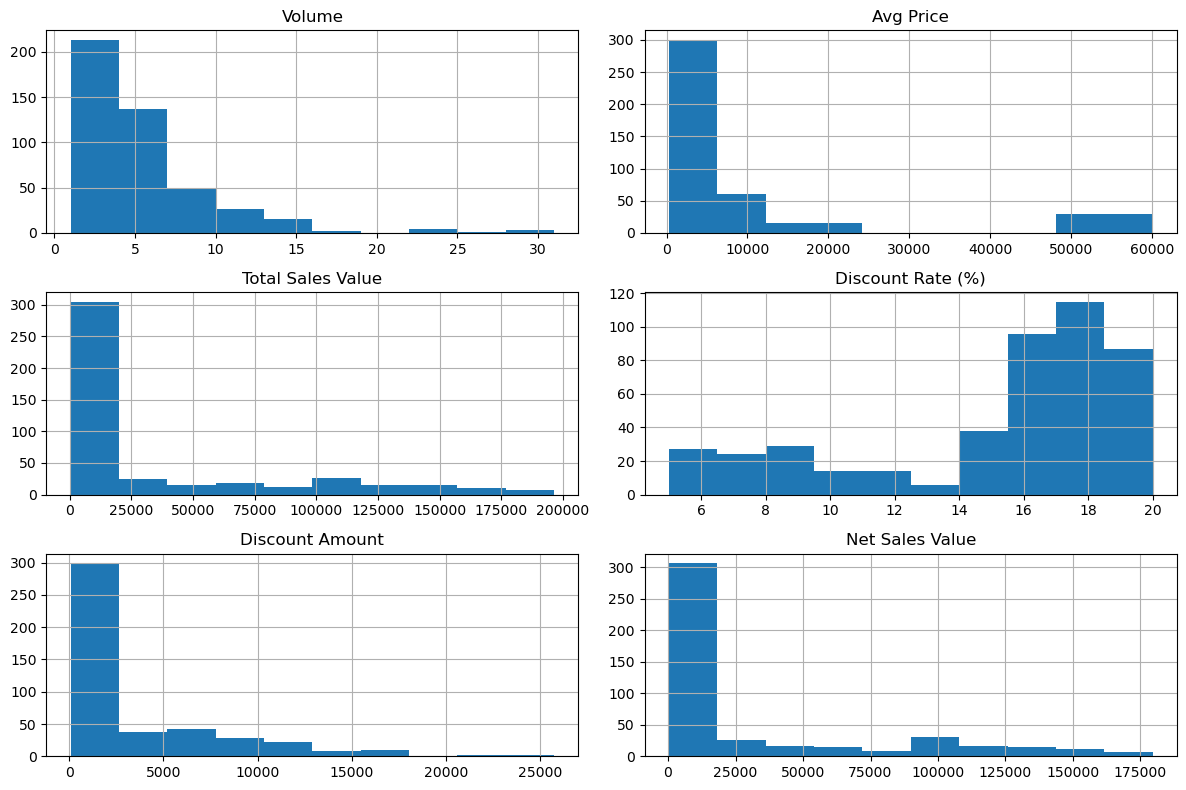

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
num_cols.hist(figsize=(12,8))#create the histrogram for all columns and set the figure size
plt.tight_layout()#make the space between the the image not to be overlap
plt.show()#display the histogram

In [ ]:
1.Volume
  Distribution : Positively skewed
  Outliers     : Few high-volume values around 21–31 indicate outliers
  Inference    : Occasional bulk purchases increase skewness

2.Average Price
  Distribution : Highly right-skewed. Majority of prices lie in the lower range
  Outliers     : Clear outliers around 50000–60000
  Inference    : A small number of expensive items significantly affect the mean

3.Total Sales Value
  Distribution : Strong Positively skewed.High sales occurs between 0-2500
  Outliers     : Extreme outliers near 150000–200000
  Inference    : Mean is much higher than median due to outliers

4.Discount Rate (%)
  Distribution : Negatively skewed.Most values clustered between 15% and 20%
  Outliers     : Few low discount values around 5–7%. Outliers can be treated with lower whisker length
  Inference    : Discounts are generally high.Lower discounts are rarely offered. 

5.Discount Amount
  Distribution : Positively skewed.
  Outliers     : Outliers is range between 20000–25000. OUtliers can be treated with upper whisker length
  Inference    : Mean discount is inflated due to outliers

6.Net Sales Value
  Distribution : Strong positive skewness.Majority of values lie in the lower sales range
  Outliers     : Extreme high values around 150000–180000 indicate outliers
  Inference    : Median is a better measure than mean for typical sales performance.Net Sales value looks similiar to total sales value.

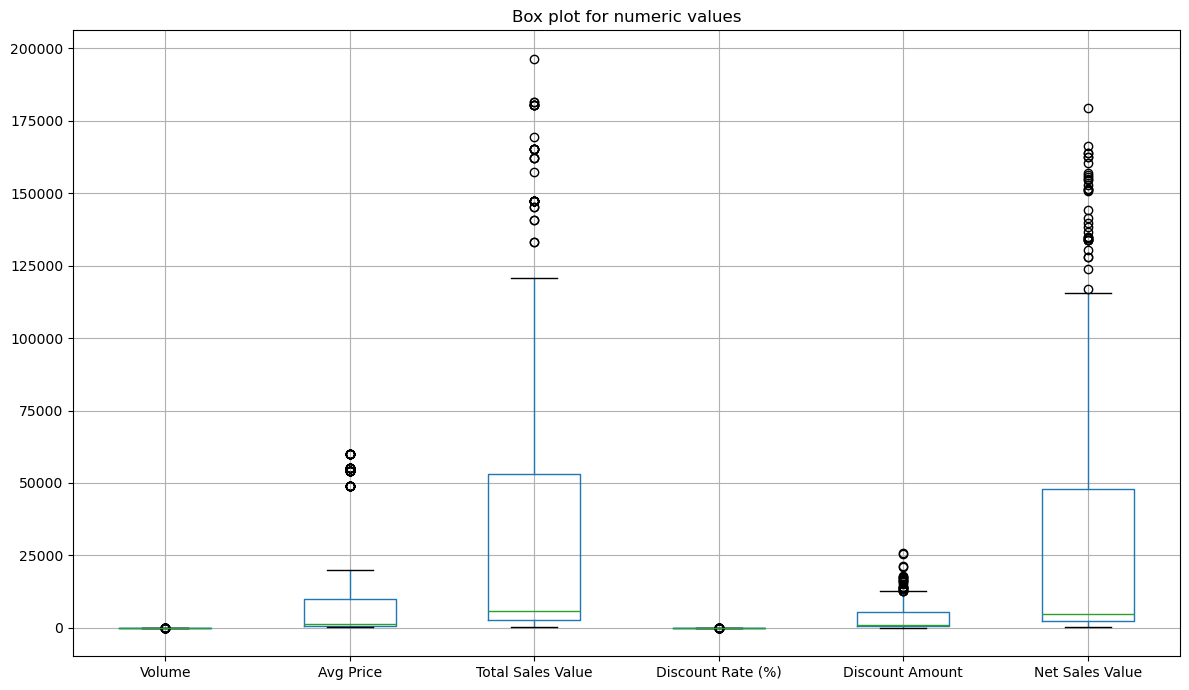

In [23]:
#Box plot
num_cols.boxplot(figsize=(12,7))#create the boxplot and set the figure size
plt.title("Box plot for numeric values")#title for boxplot
plt.tight_layout()#making the space not to be ovelap
plt.show()#display the box plot


In [25]:
#Calculate Q1,Q3 and IQR
Q1 = np.round(num_cols.quantile(0.25),2)#25%
Q3 = np.round(num_cols.quantile(0.75),2)#75%
IQR = Q3-Q1#compute 75%-25%
#DataFrame
IQR_Table=pd.DataFrame({'Q1':Q1,
                        'Q3':Q3,
                        'IQR':IQR})
print(IQR_Table)

                        Q1        Q3       IQR
Volume                3.00      6.00      3.00
Avg Price           465.00  10100.00   9635.00
Total Sales Value  2700.00  53200.00  50500.00
Discount Rate (%)    13.97     18.11      4.14
Discount Amount     460.46   5316.50   4856.04
Net Sales Value    2202.21  47847.91  45645.70


In [ ]:
The IQR is calculated as the difference between the 25th and 75th percentiles to measure data spread and identify outliers.
    
Q1 (First Quartile)
    *Q1 is the value below which 25% of the data falls.
    *It represents the lower quarter of the dataset.
    *Also called the 25th percentile.
    *25% of the observations are less than or equal to Q1.
Q3 (Third Quartile)
    *Q3 is the value below which 75% of the data falls.
    *It represents the upper quarter of the dataset.
    *Also called the 75th percentile.
    *75% of the observations are less than or equal to Q3
    
Inter-Quartile Range (IQR) = Q3 - Q1

Lower whisker limit = Q1 − 1.5 × IQR
Upper whisker limit = Q3 + 1.5 × IQR

In [ ]:
1.Volume
    Q1 = 3, Q3 = 6, IQR = 3
    
    Lower Whisker length = 3 − 4.5 = −1.5 (not meaningful)
    Upper Whisker length = 6 + 4.5 = 10.5
    
    Finding: 
         All values which is greater than 10.5 should be replaced with Upper Whisker length value

2.Average Price
    Q1 = 465, Q3 = 10100, IQR = 9635
    
    Lower whisker limit = −13987.5 (ignore)
    Upper whisker limit = 24552.5
    
    Finding: 
          Several extreme high-price outliers.
              
    Treatment needed:
         Upper whisker only

In [ ]:
3.Total Sales Value Q1 = 2700, Q3 = 53200, IQR = 50500

Lower limit = −72950 (ignore)

Upper limit = 129950

Finding:
   *Many extreme upper outliers
   *Strong right skew

Treatment needed: 
   Upper whisker only
4.Discount Rate (%) Q1 = 13.97, Q3 = 18.11, IQR = 4.14

Lower limit = 7.76

Upper limit = 24.32

Finding:
    Few lower outliers (<7.76)

Treatment needed: 
    Lower whisker only (if required)

In [ ]:
5.Discount Amount
    Q1 = 460.46, Q3 = 5316.50, IQR = 4856.04
    
    Lower limit = −6823.6 (ignore)
    
    Upper limit = 12590.56
    
    Finding:
        High discount outliers exist
    
    Treatment needed:
        Upper whisker only

6.Net Sales Value
    Q1 = 2202.21, Q3 = 47847.91, IQR = 45645.70
    
    Lower limit = −66266.3 (ignore)
    
    Upper limit = 116316.46
    
    Finding:
        Many extreme high-value outliers
    
    Treatment needed:
        Upper whisker only

In [ ]:
#●	Bar Chart Analysis for Categorical Column

In [28]:
df.select_dtypes(include=['object']).columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

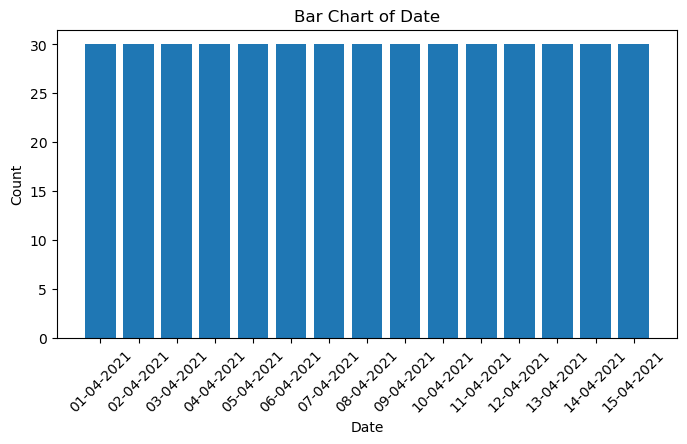

In [31]:
# 1. Date 
# Counts the frequency of each unique date in the 'Date' column
count = df['Date'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(count.index, count.values)

# Labels and title
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Bar Chart of Date")
# Rotate x labels for readability
plt.xticks(rotation=45)
plt.show()

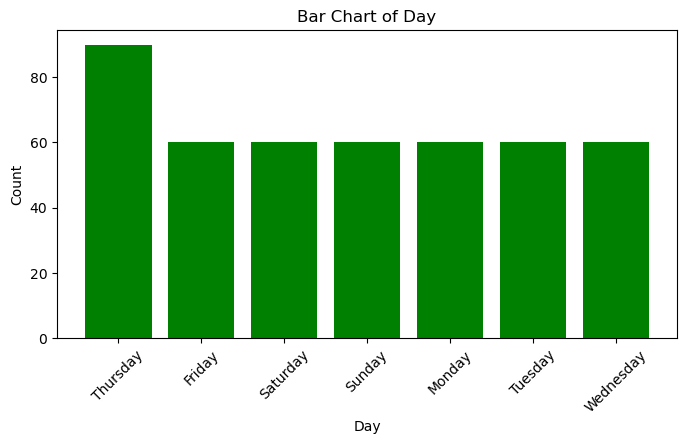

In [32]:
# 2. Day
# Counts the frequency of each unique date in the 'Day' column
count = df['Day'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(count.index, count.values,color='green')

# Labels and title
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Bar Chart of Day")
# Rotate x labels for readability
plt.xticks(rotation=45)
plt.show()

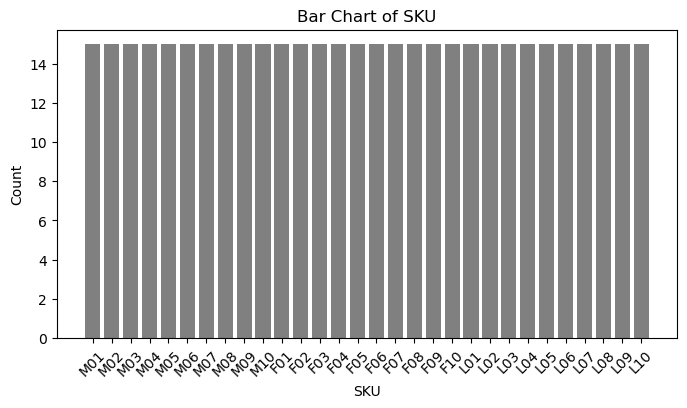

In [33]:
# 3.SKU 
# Counts the frequency of each unique date in the 'SKU' column
count = df['SKU'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(count.index, count.values,color='Gray')

# Labels and title
plt.xlabel("SKU")
plt.ylabel("Count")
plt.title("Bar Chart of SKU")
# Rotate x labels for readability
plt.xticks(rotation=45)
plt.show()

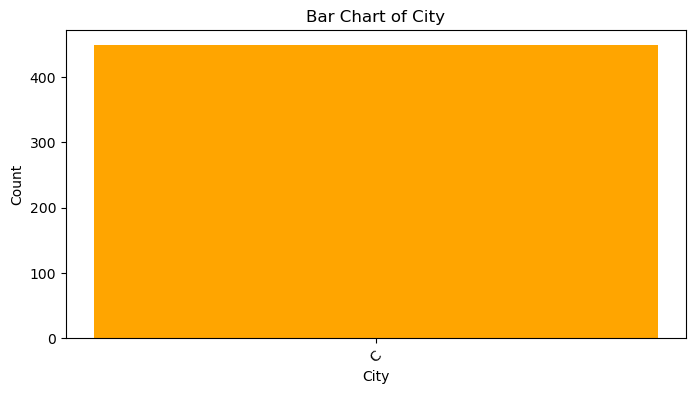

In [34]:
# 4.city
# Counts the frequency of each unique date in the 'Ci' column
count = df['City'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(count.index, count.values,color='orange')

# Labels and title
plt.xlabel("City")
plt.ylabel("Count")
plt.title("Bar Chart of City")
# Rotate x labels for readability
plt.xticks(rotation=45)
plt.show()

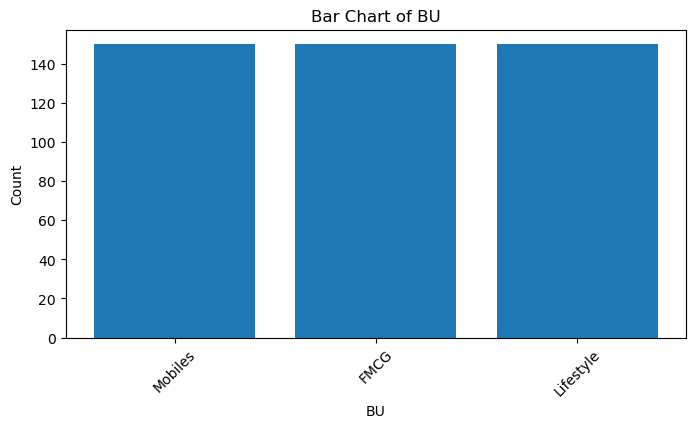

In [35]:
# 5.BU
# Counts the frequency of each unique BU in the 'BU' column
counts = df['BU'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(counts.index, counts.values)

# Labels and title
plt.xlabel("BU")
plt.ylabel("Count")
plt.title("Bar Chart of BU")
# Rotate x labels for readability
plt.xticks(rotation=45)
plt.show()

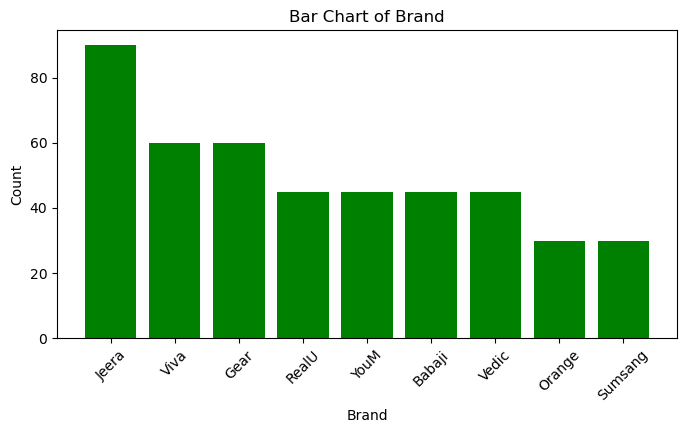

In [38]:
# 6.Brand
# Counts the frequency of each unique brand in the 'Brand' column
counts = df['Brand'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(counts.index, counts.values,color='Green')

# Labels and title
plt.xlabel("Brand")
plt.ylabel("Count")
plt.title("Bar Chart of Brand")
# Rotate x labels for readability
plt.xticks(rotation=45)
plt.show()

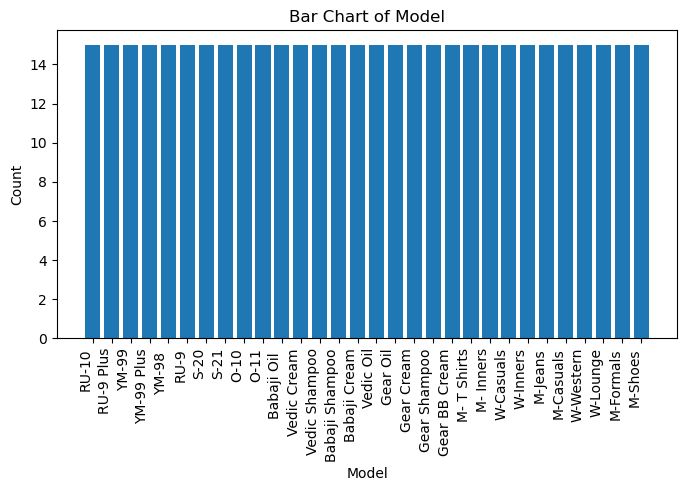

In [39]:

# 7.Model
# Counts the frequency of each unique Model in the 'Model' column
counts = df['Model'].value_counts()

# Creates a new figure with width 8 inches and height 4 inches
plt.figure(figsize=(8,4))

# Creates a bar chart with categories on the x-axis and their frequencies on the y-axis
plt.bar(counts.index, counts.values)

# Labels and title
plt.xlabel("Model")
plt.ylabel("Count")
plt.title("Bar Chart of Model")
# Rotate x labels for readability
plt.xticks(rotation=90,ha='right')
plt.show()